In [1]:
from optihelper import *

In [ ]:
def solve_large_k_decomposed(K, V_target=144, H_target=32):
    """
    Stage 1: Fix visible assignment (ignore fusion completely)
    Stage 2: Fuse hidden nodes to target (ignore connectivity optimization)
    """
    G = dnx.zephyr_graph(K)
    G_clean = remove_edge_nodes(G, min_degree=12)  # Higher threshold for large K
    
    print(f"\n=== STAGE 1: Assign Visible Nodes (K={K}) ===")
    
    # Method A: Pure heuristic (FAST)
    degrees = sorted(G_clean.nodes(), key=lambda n: G_clean.degree(n), reverse=True)
    visible_nodes = degrees[:V_target]
    
    # Method B: Or use pixel-aware heuristic
    # pixel_to_node, _ = assign_pixels_to_nodes_heuristic(G_clean, V_target, grid_shape)
    # visible_nodes = list(pixel_to_node.values())
    
    hidden_nodes = [n for n in G_clean.nodes() if n not in visible_nodes]
    
    print(f"  Visible: {len(visible_nodes)}")
    print(f"  Hidden: {len(hidden_nodes)}")
    
    print(f"\n=== STAGE 2: Fuse Hidden to Target ===")
    
    # Greedy fusion on hidden subgraph
    G_hidden = G_clean.subgraph(hidden_nodes).copy()
    G_work = G_clean.copy()
    
    target_fusions = len(hidden_nodes) - H_target
    fusions_done = 0
    hidden_remaining = set(hidden_nodes)
    
    print(f"  Need {target_fusions} fusions")
    
    while fusions_done < target_fusions and len(hidden_remaining) > H_target:
        # Find lowest-degree hidden node
        degrees = [(n, G_work.degree(n)) for n in hidden_remaining]
        if not degrees:
            break
        degrees.sort(key=lambda x: x[1])
        
        node1 = degrees[0][0]
        hidden_neighbors = [nb for nb in G_work.neighbors(node1) 
                           if nb in hidden_remaining and nb != node1]
        
        if not hidden_neighbors:
            G_work.remove_node(node1)
            hidden_remaining.discard(node1)
            fusions_done += 1
            continue
        
        node2 = min(hidden_neighbors, key=lambda n: G_work.degree(n))
        G_work = nx.contracted_nodes(G_work, node1, node2, self_loops=False)
        hidden_remaining.discard(node2)
        fusions_done += 1
        
        if fusions_done % 100 == 0:
            print(f"    {fusions_done}/{target_fusions} fusions...")
    
    final_hidden = list(hidden_remaining)
    final_visible = [v for v in visible_nodes if v in G_work.nodes()]
    
    print(f"\n Complete: {len(final_visible)} visible, {len(final_hidden)} hidden")
    
    return G_work, final_visible, final_hidden


In [3]:

def build_and_solve(K, V_target, H_target, tee=False, initial_visible_assignment=None): # new parameter initial_visible_assignment
    # Build Zephyr graph
    G = dnx.zephyr_graph(K)
    nodes = sorted(G.nodes())
    n = len(nodes)
    node_index = {i: idx for idx, i in enumerate(nodes)}

    edges = sorted(set((min(u, v), max(u, v)) for u, v in G.edges()))

    adj = {i: set() for i in nodes}
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)

    P = edges.copy()
    # P = [(i, j) for i in nodes for j in nodes if i < j]  # All pairs

    triples = []
    for (k, l) in P:
        common_neighbors = set(adj[k]).intersection(adj[l])
        for i in common_neighbors:
            triples.append((i, k, l))
    triples = list(set(triples))

    if not (0 <= V_target <= n):
        raise ValueError("V_target out of range")
    if not (0 <= H_target <= n):
        raise ValueError("H_target out of range")
    f_required = (n - V_target) - H_target
    if f_required < 0:
        raise ValueError(f"Impossible targets: need nonnegative fusions, got {f_required}")

    
    # Build SCIP model
    
    m = Model("NodeLabelOptimization")

    #  Variables 
    relax = False  # <-- toggle

    x = {i: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"x_{i}") for i in nodes}
    z = {p: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"z_{p[0]}_{p[1]}") for p in P}
    y = {e: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"y_{e[0]}_{e[1]}") for e in edges}
    u = {t: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"u_{t[0]}_{t[1]}_{t[2]}") for t in triples}
    t_var = m.addVar(vtype="I", lb=0, name="t")

    # If initial visible assignment provided, use it as starting point
    if initial_visible_assignment is not None and not relax:
        initial_visible = set(initial_visible_assignment.values())
        print(f"Creating warm start with {len(initial_visible)} pre-assigned visible nodes")
        
        # Create a heuristic solution
        heur_sol = m.createPartialSol()
        
        # Set x variables based on initial assignment
        for i in nodes:
            if i in initial_visible:
                m.setSolVal(heur_sol, x[i], 1.0)
            else:
                m.setSolVal(heur_sol, x[i], 0.0)
        
        # Don't set z variables yet - let solver figure out fusions
        # Add the partial solution
        m.addSol(heur_sol, free=True)  # free=True allows solver to modify it
        print("Warm start added")

    
    # Constraints
    
    # 1) Visible node count
    m.addCons(quicksum(x[i] for i in nodes) == V_target, "visible_count")

    # # 2) Hidden target: sum x_i + sum z_kl = n - H_target
    m.addCons(quicksum(x[i] for i in nodes) + quicksum(z[p] for p in P) == n - H_target, "hidden_target")

    # # 2b) After fusions:
    # # - V-V fusions reduce visible count by 1 (two visible -> one visible)
    # # - H-H fusions reduce hidden count by 1 (two hidden -> one hidden)
    # # Let: vv_fusions = sum of z[(k,l)] where both k,l are initially visible
    # #      hh_fusions = sum of z[(k,l)] where both k,l are initially hidden

    # vv_fusion_sum = quicksum(z[(k,l)] * x[k] * x[l] for (k,l) in P)  # Approximate
    # hh_fusion_sum = quicksum(z[(k,l)] * (1-x[k]) * (1-x[l]) for (k,l) in P)  # Approximate

    # # Visible after fusion: V_target (initial) - vv_fusions
    # # Hidden after fusion: (n - V_target) (initial) - hh_fusions
    # # Constraint: Hidden after fusion = H_target
    # # So: (n - V_target) - hh_fusions = H_target
    # # Therefore: hh_fusions = n - V_target - H_target

    # m.addCons(hh_fusion_sum == n - V_target - H_target, "hidden_target_with_fusion")

    # Debug: Is the hidden target even achievable?
    print(f"\nFeasibility check:")
    print(f"  Total nodes: {n}")
    print(f"  Target visible: {V_target}")
    print(f"  Target hidden: {H_target}")
    print(f"  Required fusions: {n - V_target - H_target}")
    print(f"  Maximum possible fusions (with matching): {len([i for i in nodes if len(adj[i]) > 0])}")

    # Debug: check if basic constraints are consistent
    m.addCons(quicksum(x[i] for i in nodes) + quicksum(z[p] for p in P) == n - H_target, "hidden_target")
    print(f" Added constraint: sum(x) + sum(z) = {n - H_target}")
    print(f"  This means: {V_target} visible + {n - V_target - H_target} fusions → {H_target} hidden")

    
    
    # # 3) Fusion only among hidden nodes
    for (k, l) in P:
        m.addCons(z[(k, l)] <= 1 - x[k], f"fusion1_{k}_{l}")
        m.addCons(z[(k, l)] <= 1 - x[l], f"fusion2_{k}_{l}")

    # # 3b) Fusion rules: Allow V-V fusion, but result must stay visible
    # # If both visible: fusion creates a new visible node
    # # If both hidden: fusion creates a new hidden node
    # # No V-H fusion (would be ambiguous)

    # # Add variable to track if fusion result is visible
    # z_result_visible = {p: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, 
    #                                 name=f"zv_{p[0]}_{p[1]}") for p in P}

    # for (k, l) in P:
    #     # If both k,l are visible, fusion result must be visible
    #     # z_result_visible[(k,l)] >= x[k] + x[l] - 1
    #     m.addCons(z_result_visible[(k, l)] >= x[k] + x[l] - 1, f"vv_fusion1_{k}_{l}")
        
    #     # If fusion happens and both visible, result is visible
    #     # z_result_visible[(k,l)] <= (x[k] + x[l])/2 + M*(1-z[(k,l)])
    #     # Simplified: if z=1 and both x=1, then z_result_visible=1
    #     m.addCons(z_result_visible[(k, l)] <= x[k], f"vv_fusion2_{k}_{l}")
    #     m.addCons(z_result_visible[(k, l)] <= x[l], f"vv_fusion3_{k}_{l}")
        
    #     # No V-H fusion: if one is visible and one hidden, can't fuse
    #     # z[(k,l)] <= 1 - |x[k] - x[l]|
    #     # Use y[(k,l)] which already computes |x[k] - x[l]|
    #     if (min(k,l), max(k,l)) in y:
    #         m.addCons(z[(k, l)] <= 1 - y[(min(k, l), max(k, l))], f"no_vh_fusion_{k}_{l}")

    # # 4) Matching constraint: node participates in ≤ 1 fusion
    # for i in nodes:
    #     nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
    #     if nbrs:
    #         m.addCons(quicksum(z[p] for p in nbrs) <= 1 - x[i], f"match_{i}")

    # 5) Linearize y_ij = |x_i - x_j|
    for (i, j) in edges:
        m.addCons(y[(i, j)] >= x[i] - x[j])
        m.addCons(y[(i, j)] >= x[j] - x[i])
        m.addCons(y[(i, j)] <= x[i] + x[j])
        m.addCons(y[(i, j)] <= 2 - (x[i] + x[j]))

    # 6) Linearize u_{i,kl} = x_i * z_{kl}
    for (i, k, l) in triples:
        m.addCons(u[(i, k, l)] <= x[i])
        m.addCons(u[(i, k, l)] <= z[(k, l)])
        m.addCons(u[(i, k, l)] >= x[i] + z[(k, l)] - 1)

    # 7) Maximin constraint: t <= c_i + M*x_i
    max_deg = max(len(adj[i]) for i in nodes)
    M = max_deg
    for i in nodes:
        c_i0 = quicksum(y[(min(i, j), max(i, j))] for j in adj[i])
        losses = quicksum(u[t] for t in triples if t[0] == i)
        c_i_expr = c_i0 - losses
        m.addCons(t_var <= c_i_expr + M * x[i], f"maximin_{i}")

    # 8) Upper bound for t
    m.addCons(t_var <= max_deg, "t_upper")

    # 8b) Lower bound for t based on empirical evidence
    m.addCons(t_var >= 4, "t_lower_bound")
    print("Added constraint: t >= 4 (empirically achievable)")


    # Objective: maximize t
    m.setObjective(t_var, "maximize")

    # m.setObjective(quicksum(z[p] for p in P), "maximize")  # Just maximize fusions

   
    # Solve
    m.setParam("limits/time", 60)
    m.setParam("display/verblevel", 5 if tee else 0)
    m.setParam("limits/gap", 0.1)

    print(f"K={K}, n={n}, V_target={V_target}, H_target={H_target}")
    print(f"f_required = {(n - V_target) - H_target}")
    print(f"Max possible fusions (n/2) = {n//2}")
    print(f"Total edges = {len(edges)}")

    # Debug: check if basic constraints are consistent
    print("\nPre-solve check:")
    print(f"  Nodes: {len(nodes)}")
    print(f"  V_target: {V_target}")
    print(f"  H_target: {H_target}")
    print(f"  Required fusions: {n - V_target - H_target}")
    print(f"  Available fusion pairs: {len(P)}")

    if (n - V_target - H_target) > len(P):
        print("  WARNING: Not enough fusion pairs available!")
    m.optimize()

    status = m.getStatus()
    print(f"Solver status: {status}")

    # Debug
    # actual_fusions = sum(1 for val in z_vals.values() if val > 0.5)
    # print(f"\nConstraint check:")
    # print(f"  sum(x) = {sum(x_vals.values())}")
    # print(f"  sum(z) = {sum(z_vals.values())} (actual: {actual_fusions} binary)")
    # print(f"  sum(x) + sum(z) = {sum(x_vals.values()) + sum(z_vals.values())}")
    # print(f"  Target: {n - H_target}")
    # print(f"  Difference: {abs(sum(x_vals.values()) + sum(z_vals.values()) - (n - H_target))}")

    # Extract results
   
    # after m.optimize() and checking m.getNSols() > 0
    sol = m.getBestSol()

    # Time limit reached without feasible solution
    if sol is None:
        print(" NO SOLUTION FOUND: Solver hit time limit before finding feasible solution.")
        print("   Returning empty solution:")
        return {
            "model": m,
            "x": {i: 0.0 for i in nodes},
            "z": {p: 0.0 for p in P},
            "y": {e: 0.0 for e in edges},
            "u": {t: 0.0 for t in triples},
            "t": 0.0,
            "c0": {i: 0.0 for i in nodes},
            "losses": {i: 0.0 for i in nodes},
            "c_eff": {i: 0.0 for i in nodes},
            "G_original": G,
            "G_contracted": G.copy(),
            "fused_map": {}
        }

    # raw floats
    x_vals = {i: m.getSolVal(sol, x[i]) for i in nodes}
    z_vals = {p: m.getSolVal(sol, z[p]) for p in P}
    y_vals = {e: m.getSolVal(sol, y[e]) for e in edges}
    u_vals = {t: m.getSolVal(sol, u[t]) for t in triples}
    t_val = m.getSolVal(sol, t_var)

    # quick summaries
    print("SUM x (float) =", sum(x_vals.values()))
    print("SUM z (float) =", sum(z_vals.values()))
    print("SUM y (float) =", sum(y_vals.values()))
    print("t (float) =", t_val)

    # show top nonzero vars
    print("Top x (nonzero):", [(i, round(x_vals[i],3)) for i in nodes if x_vals[i] > 1e-6][:20])
    print("Top z (nonzero):", [(p, round(z_vals[p],3)) for p in P if z_vals[p] > 1e-6][:20])
    print("Top y (nonzero):", [(e, round(y_vals[e],3)) for e in edges if y_vals[e] > 1e-6][:20])

    # Compute effective c_i
    c0 = {}
    losses = {}
    c_eff = {}
    for i in nodes:
        nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
        c0[i] = sum(y_vals.get(p, 0.0) for p in nbrs)
        losses[i] = sum(u_vals.get(t, 0.0) for t in triples if t[0] == i)
        c_eff[i] = c0[i] - losses[i]

  
   
    # Build contracted graph (apply fusions)
    G_contracted = G.copy()
    fused_map = {}  # maps original node to final representative

    # Group fusions by connected components
    fusion_edges = [(k, l) for (k, l), val in z_vals.items() if val > 0.99]  # use threshold for float tolerance

    # Build fusion graph to find connected components
    fusion_graph = nx.Graph()
    fusion_graph.add_nodes_from(nodes)
    fusion_graph.add_edges_from(fusion_edges)

    # Each connected component gets fused into one node
    for component in nx.connected_components(fusion_graph):
        if len(component) == 1:
            continue  # singleton, no fusion needed
        
        # Pick representative (eg, smallest node)
        rep = min(component)
        rep_name = "_".join(map(str, sorted(component)))
        
        # Collect all neighbors from all nodes in component
        all_neighbors = set()
        for node in component:
            if node in G_contracted:
                all_neighbors.update(G_contracted.neighbors(node))
        
        # Remove nodes being fused from neighbor set
        all_neighbors -= component
        
        # Add new representative node
        if rep_name not in G_contracted:
            G_contracted.add_node(rep_name)
        
        # Connect representative to all external neighbors
        for nb in all_neighbors:
            if nb not in component:  # don't self-loop
                G_contracted.add_edge(rep_name, nb)
        
        # Remove original nodes
        for node in component:
            if node in G_contracted:
                G_contracted.remove_node(node)
            fused_map[node] = rep_name

    print(f"Objective t = {t_val}")
    print("Visible nodes (x_i=1):", [i for i, xv in x_vals.items() if xv == 1])
    print("Fusions (z_{k,l}=1):", [p for p, zv in z_vals.items() if zv == 1])
    print("Effective cross-edges per node (c_eff):")
    for i in nodes:
        print(f" node {i}: x={x_vals[i]}, c0={c0[i]}, losses={losses[i]}, c_eff={c_eff[i]}")

    return {
        "model": m,
        "x": x_vals,
        "z": z_vals,
        "y": y_vals,
        "u": u_vals,
        "t": t_val,
        "c0": c0,
        "losses": losses,
        "c_eff": c_eff,
        "G_original": G,
        "G_contracted": G_contracted,
        "fused_map": fused_map
    }


In [4]:
K = 5
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
nodes = sorted(G.nodes())
print('K =', K, 'n =', n, 'n/K =', n/K, 'n/(32*K^2) =', n/(32*K**2+16*K))
print("Toal number of edges:", G.number_of_edges())
V_target = 144 
H_target =  32 


# Call this before building SCIP model:
# max_possible = analyze_fusion_potential(G, nodes, V_target)
# required = (n - V_target) - H_target

# if max_possible < required:
#     print(f"\n INFEASIBLE: Graph structure allows only {max_possible} fusions, need {required}!")
#     print(f"   → H_target={H_target} is impossible. Minimum achievable: {n - V_target - max_possible}")

K = 5 n = 880 n/K = 176.0 n/(32*K^2) = 1.0
Toal number of edges: 7896


In [5]:
# Use before optimization:
G_original = dnx.zephyr_graph(K)
df_analysis = analyze_zephyr_layout(G_original, K)



 Top 20 nodes by degree 
    node  degree         x         y  dist_from_center
41    41      20  0.092352 -0.269841          0.468626
42    42      20  0.092352 -0.454545          0.410573
43    43      20  0.092352 -0.639250          0.431000
46    46      20  0.099567 -0.362193          0.423941
47    47      20  0.099567 -0.546898          0.403486
48    48      20  0.099567 -0.731602          0.462718
51    51      20  0.115440 -0.269841          0.448668
52    52      20  0.115440 -0.454545          0.387638
53    53      20  0.115440 -0.639250          0.409211
56    56      20  0.122655 -0.362193          0.402184
57    57      20  0.122655 -0.546898          0.380562
58    58      20  0.122655 -0.731602          0.442870
61    61      20  0.138528 -0.269841          0.429025
62    62      20  0.138528 -0.454545          0.364722
63    63      20  0.138528 -0.639250          0.387573
66    66      20  0.145743 -0.362193          0.380584
67    67      20  0.145743 -0.546898   

Removing 64 edge nodes (degree < 12)
  Original nodes: 880
  Cleaned nodes: 816
  Degree distribution after cleaning: min=10, max=20

=== STAGE 1: Assign Visible Nodes (K=5) ===
  Visible: 144
  Hidden: 672

=== STAGE 2: Fuse Hidden to Target ===
  Need 640 fusions
    100/640 fusions...
    200/640 fusions...
    300/640 fusions...
    400/640 fusions...
    500/640 fusions...
    600/640 fusions...

✓ Complete: 144 visible, 32 hidden


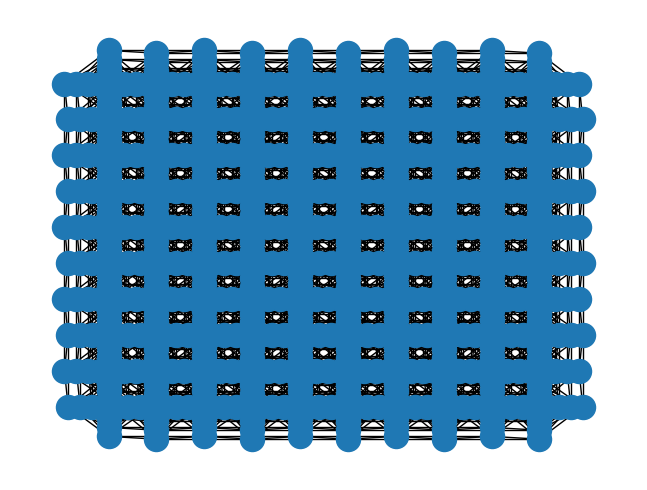

In [6]:
grid_shape = (12, 12)
dnx.draw_zephyr(G)

# # Use BEFORE optimization:
# G_clean = remove_edge_nodes(
#         G_original, min_degree= 18)  # Adjust threshold as needed

# # Use before optimization:
# # G_reduced = preprocess_graph(G_clean, V_target=144, H_target=32)

#  # Step 1: Pixel-to-node assignment
# pixel_to_node, node_to_pixel = assign_pixels_to_nodes_heuristic(
#     G_clean, num_pixels=V_target, grid_shape=grid_shape)
    
# initial_visible_nodes = set(pixel_to_node.values())

G, visible_nodes, hidden_nodes = solve_large_k_decomposed(K, 144, 32)
# set targets
 
# sol = build_and_solve(K=K, V_target=V_target, H_target=H_target, tee=True, initial_visible_assignment=pixel_to_node)
# x_vals = sol["x"]
# z_vals = sol["z"]
# G_new = sol["G_original"]
# print(x_vals)

In [7]:
# G_fused, visible_nodes, hidden_nodes, clean_to_fused = apply_fusions_to_graph_clean(
#     G_new, 
#     x_vals, 
#     z_vals,
# )

# # Stage 2: Greedy post-processing to reach exact target
# G_contracted, visible_nodes, hidden_nodes = postprocess_fuse_hidden(
#     G_fused, visible_nodes, hidden_nodes, H_target=32)


# print(f"\nFinal result:")
# print(f"  Visible: {len(visible_nodes)} (target: 144)")
# print(f"  Hidden: {len(hidden_nodes)} (target: 32)")

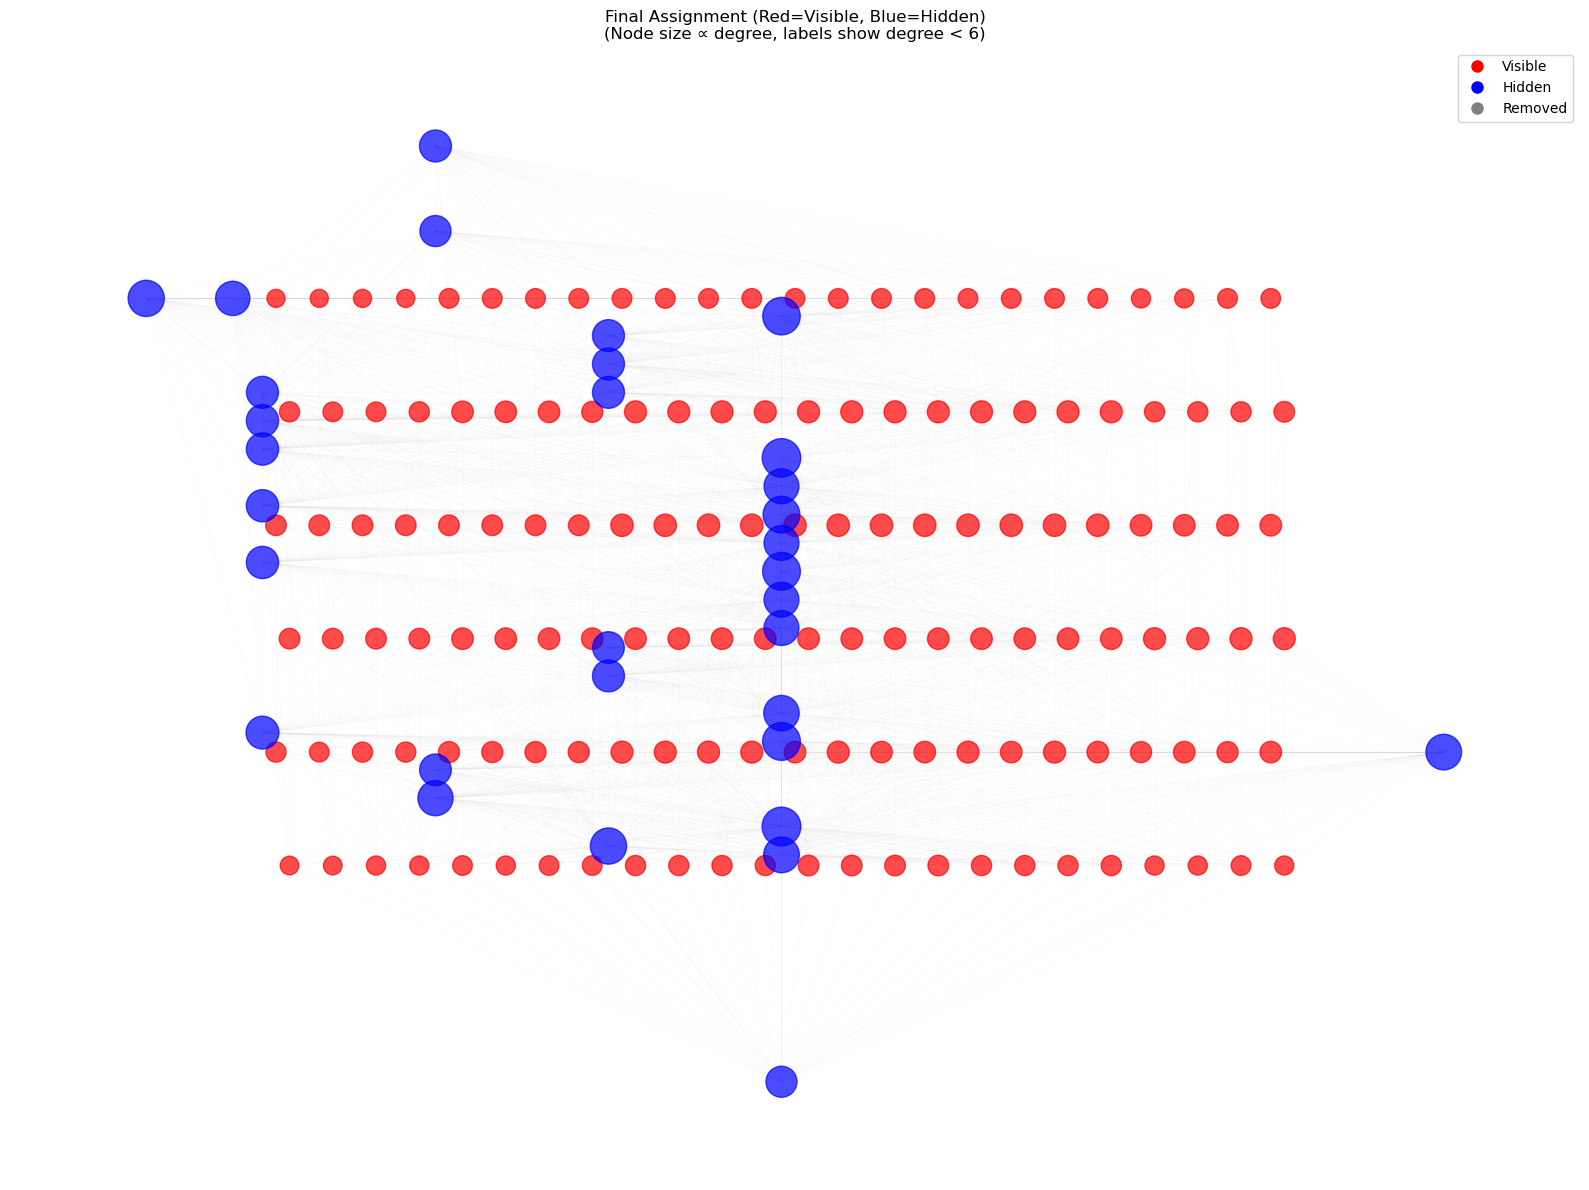

In [8]:
# After optimization and post-processing:
# G_contracted = G_fused
visualize_node_assignment_on_zephyr(G, visible_nodes, hidden_nodes, 
                                    title="Final Assignment (Red=Visible, Blue=Hidden)")

In [9]:


# print(f"\nAfter fusion:")
# print(f"  Original nodes: {sol['G_original'].number_of_nodes()}")
# print(f"  Contracted nodes: {G_contracted.number_of_nodes()}")
# print(f"  Visible: {len(visible_nodes)}")
# print(f"  Hidden: {len(hidden_nodes)}")
# print(f"  Expected hidden: {H_target}")

# 3. Relabel for training
G, visible_nodes, hidden_nodes, relabel_mapping = relabel_for_training(
    G, visible_nodes, hidden_nodes
)

print(f"\nRelabeled graph:")
print(f"  Visible node IDs: 0 to {len(visible_nodes)-1}")
print(f"  Hidden node IDs: {len(visible_nodes)} to {len(visible_nodes)+len(hidden_nodes)-1}")

# # Now use G_contracted as your G for the rest of the pipeline
# G = G_contracted

# 4. Create training structures
# Create vh_nodearray (1 for visible, 0 for hidden)
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int)

# Mark visible nodes as 1
for v in visible_nodes:
    vh_nodearray[v] = 1

# Create node_labels dictionary
node_labels = {i: ('visible' if vh_nodearray[i] == 1 else 'hidden') 
               for i in range(n)}

# Update global variables
NUM_VISIBLE = len(visible_nodes)
NUM_HIDDEN = len(hidden_nodes)

print(f"\n✓ Ready for training:")
print(f"  Total nodes: {n}")
print(f"  Visible nodes: {NUM_VISIBLE}")
print(f"  Hidden nodes: {NUM_HIDDEN}")
print(f"  vh_nodearray shape: {vh_nodearray.shape}")

# Annotate graph with layer info
for v in visible_nodes:
    G.nodes[v]["layer"] = "visible"
for h in hidden_nodes:
    G.nodes[h]["layer"] = "hidden"

Relabeling complete:
  Old node types: {'int'}
  New node IDs: all integers [0, 175]

Relabeled graph:
  Visible node IDs: 0 to 143
  Hidden node IDs: 144 to 175

✓ Ready for training:
  Total nodes: 176
  Visible nodes: 144
  Hidden nodes: 32
  vh_nodearray shape: (176,)


 Cross-edges (V-H): 1362 out of 1712
 Visible nodes: 144
 Hidden nodes: 32


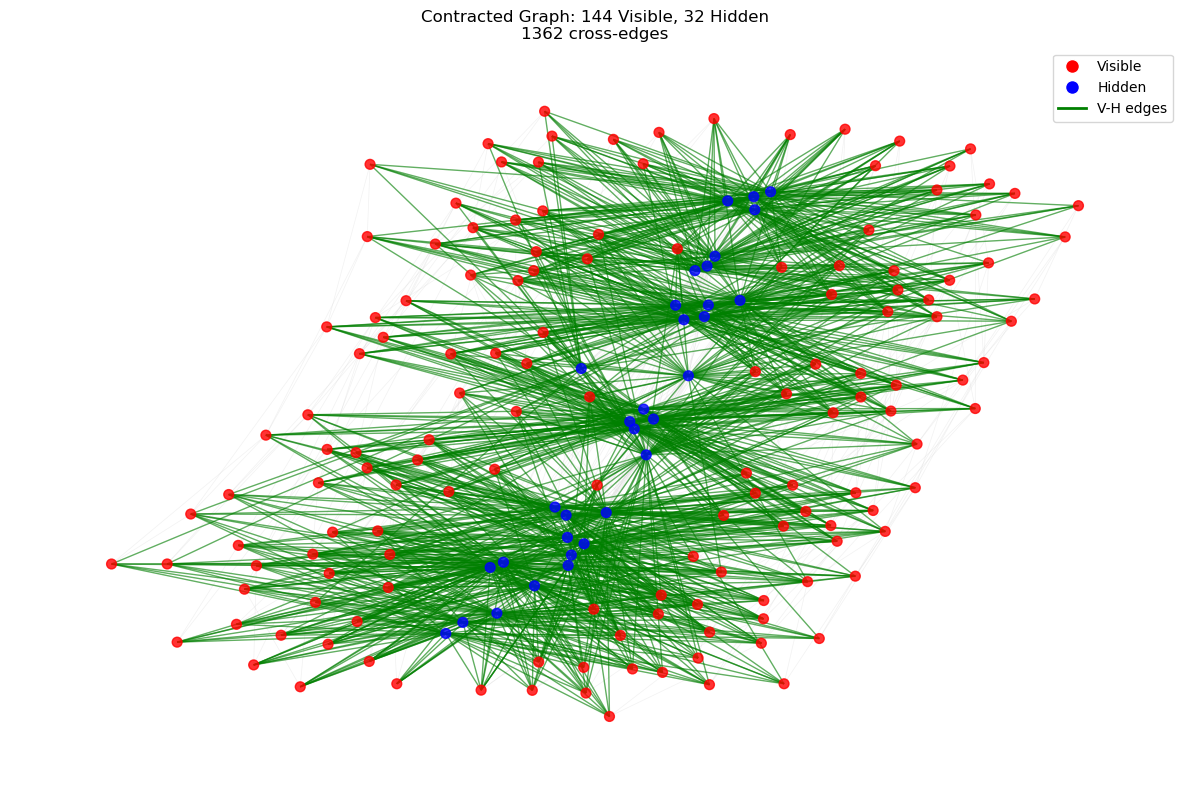

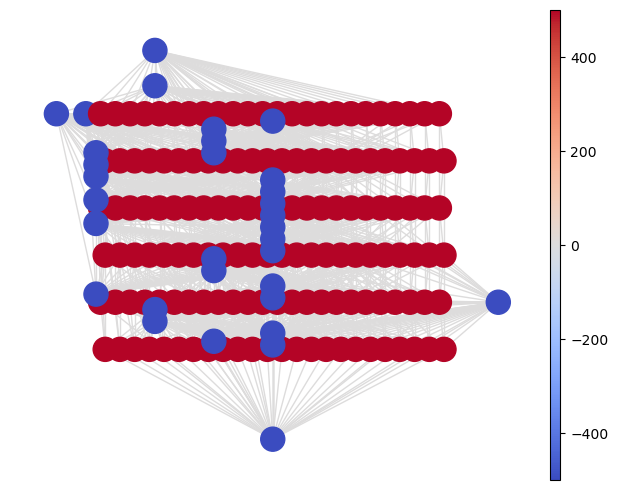

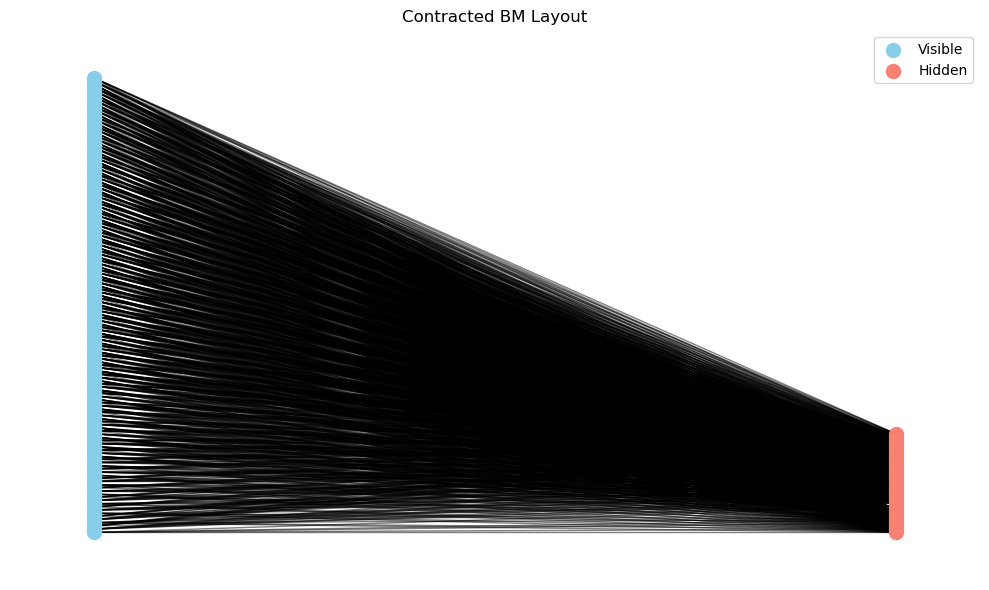

In [10]:
from bolmaqua import *
# Visualize the contracted, relabeled graph
x_sol = visualize_contracted_graph(G, visible_nodes, hidden_nodes, use_zephyr_layout=False)

# original Zephyr visualization (if it works with contracted graph)
try:
    draw_zephyr_hidden_visible(G, vh_nodearray)
except Exception as e:
    print(f"Note: Zephyr visualization doesn't work on contracted graph: {e}")


# Use the bipartite layout from your bolmaqua.py
visualize_bm_bipartite_layout(G, node_labels, title="Contracted BM Layout")

Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([200, 144])


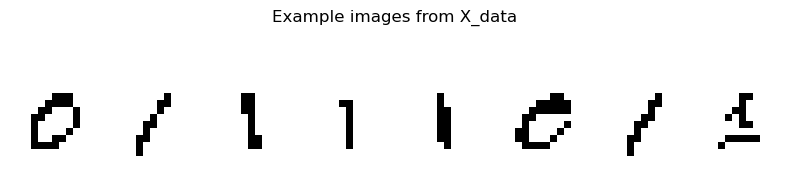

In [11]:

# --- Dataset Loading ---
# Using torchvision to download MNIST and then resize
def generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE, cutoff=0.5):
    """
    Generates downsized MNIST .npy files (from torchvision MNIST, not CSV).
    Resizes 28x28 MNIST images to `grid_shape` (e.g., 12x12, 13x13).
    Saves features and labels as .npy for reuse.
    """
    os.makedirs(output_dir, exist_ok=True)

    def process_dataset(dataset, cutoff):
        downsized, labels = [], []
        for img, label in dataset:
            # torchvision MNIST returns a PIL image unless transform is ToTensor
            img_np = np.array(img, dtype=np.float32)

            # If shape is (28,28,1), squeeze it
            if img_np.ndim == 3:
                img_np = img_np.squeeze(-1)

            img_np = img_np / 255.0  # scale to [0,1]
            img_small = resize(img_np, grid_shape, order=1, anti_aliasing=True, preserve_range=True)

            img_bin = (img_small >= cutoff).astype(np.uint8)
            downsized.append(img_bin.flatten())
            labels.append(label)
        return np.array(downsized), np.array(labels)

    # Load MNIST from torchvision (downloads automatically if not present)
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=None)
    test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

    for split, dataset in [("train", train_data), ("test", test_data)]:
        out_feats = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}feats.npy")
        out_labels = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}labels.npy")
        if not (os.path.exists(out_feats) and os.path.exists(out_labels)):
            print(f"Generating {out_feats} and {out_labels}...")
            feats, labels = process_dataset(dataset, cutoff)
            print("Processed feats shape:", feats.shape) # Debug print
            np.save(out_feats, feats)
            np.save(out_labels, labels)
        else:
            print(f"Found existing {out_feats} and {out_labels}.")

    return (
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainfeats.npy")),
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainlabels.npy"))
    )



# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
num_images_to_use = 200
mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())
# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float()
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
dummy_labels = torch.zeros(len(X_data))  
dataset = torch.utils.data.TensorDataset(X_data, dummy_labels)

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

In [12]:
# Create fresh node_labels dictionary
node_labels = {}
for node in G.nodes():
    if node in visible_nodes:
        node_labels[node] = 'visible'
    elif node in hidden_nodes:
        node_labels[node] = 'hidden'
    else:
        print(f"Warning: Node {node} not in visible or hidden lists!")
        node_labels[node] = 'hidden'  # Default to hidden

# Verify all nodes are covered
print(f"\n=== Node Label Check ===")
print(f"  Graph nodes: {G.number_of_nodes()}")
print(f"  Labeled nodes: {len(node_labels)}")
print(f"  Visible labeled: {sum(1 for v in node_labels.values() if v == 'visible')}")
print(f"  Hidden labeled: {sum(1 for v in node_labels.values() if v == 'hidden')}")

if set(G.nodes()) != set(node_labels.keys()):
    missing = set(G.nodes()) - set(node_labels.keys())
    extra = set(node_labels.keys()) - set(G.nodes())
    print(f" Mismatch detected!")
    print(f"    Missing from labels: {missing}")
    print(f"    Extra in labels: {extra}")
    raise ValueError("Graph nodes and node_labels keys don't match!")


=== Node Label Check ===
  Graph nodes: 176
  Labeled nodes: 176
  Visible labeled: 144
  Hidden labeled: 32


V-V edges: 216, H-H edges: 134, V-H edges: 1362
Building Boltzmann Machine from graph... 🏗️
Sanity check:
  dataset feature dim: 144
  model num_visible   : 144
  model num_hidden    : 32
  W_vh shape (should be V x H): (144, 32)
Starting PCD training on cpu for 50 epochs... 🏋️
Epoch 1/50 | Avg PCD Loss: 0.0000 | PLL: -0.6363
Epoch 2/50 | Avg PCD Loss: 0.0000 | PLL: -0.5552
Epoch 3/50 | Avg PCD Loss: 0.0000 | PLL: -0.4785
Epoch 4/50 | Avg PCD Loss: 0.0000 | PLL: -0.4304
Epoch 5/50 | Avg PCD Loss: 0.0000 | PLL: -0.4173
Epoch 6/50 | Avg PCD Loss: 0.0000 | PLL: -0.3534
Epoch 7/50 | Avg PCD Loss: 0.0000 | PLL: -0.3548
Epoch 8/50 | Avg PCD Loss: 0.0000 | PLL: -0.3582
Epoch 9/50 | Avg PCD Loss: 0.0000 | PLL: -0.3150
Epoch 10/50 | Avg PCD Loss: 0.0000 | PLL: -0.2687
Epoch 11/50 | Avg PCD Loss: 0.0000 | PLL: -0.3047
Epoch 12/50 | Avg PCD Loss: 0.0000 | PLL: -0.3360
Epoch 13/50 | Avg PCD Loss: 0.0000 | PLL: -0.3172
Epoch 14/50 | Avg PCD Loss: 0.0000 | PLL: -0.2725
Epoch 15/50 | Avg PCD Loss: 0.

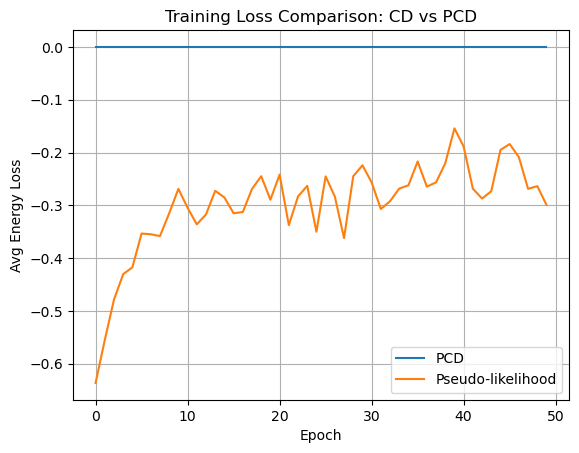

In [13]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.00175 # You can change this value for experiments 
l2_amount = 0.00175 # L2 regularization amount
num_epochs = 50
batch_size = 20
num_gibbs_steps = 1000
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



# # Print some graph statistics
# print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
# vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
# hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
# vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
# print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visible_set = set(visible_nodes)
hidden_set = set(hidden_nodes)

vv_edges = sum(1 for u, v in G.edges() if u in visible_set and v in visible_set)
hh_edges = sum(1 for u, v in G.edges() if u in hidden_set and v in hidden_set)
vh_edges = sum(1 for u, v in G.edges() if (u in visible_set) != (v in visible_set))

print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")


# visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)


# Sanity check
print("Sanity check:")
print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
W_vv.zero_() # disables v-v connections
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)


# --- Training ---
optimizer_pcd = torch.optim.Adam(model_pcd.parameters(), lr=step_size, weight_decay=l2_amount)
pcd_losses, pll_values = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, 
                                         batch_size=batch_size, step_size=step_size)

# check_fusion_strength(model_pcd, fused_pairs_remapped)
# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.plot(pll_values, label="Pseudo-likelihood")
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()

Running Gibbs sampler for 10 samples, 1000 burn-in steps each... 🔥
  Gibbs sample 1/10
  Gibbs sample 2/10
  Gibbs sample 3/10
  Gibbs sample 4/10
  Gibbs sample 5/10
  Gibbs sample 6/10
  Gibbs sample 7/10
  Gibbs sample 8/10
  Gibbs sample 9/10
  Gibbs sample 10/10
Gibbs sampling complete.

Displaying generated images... 🖼️


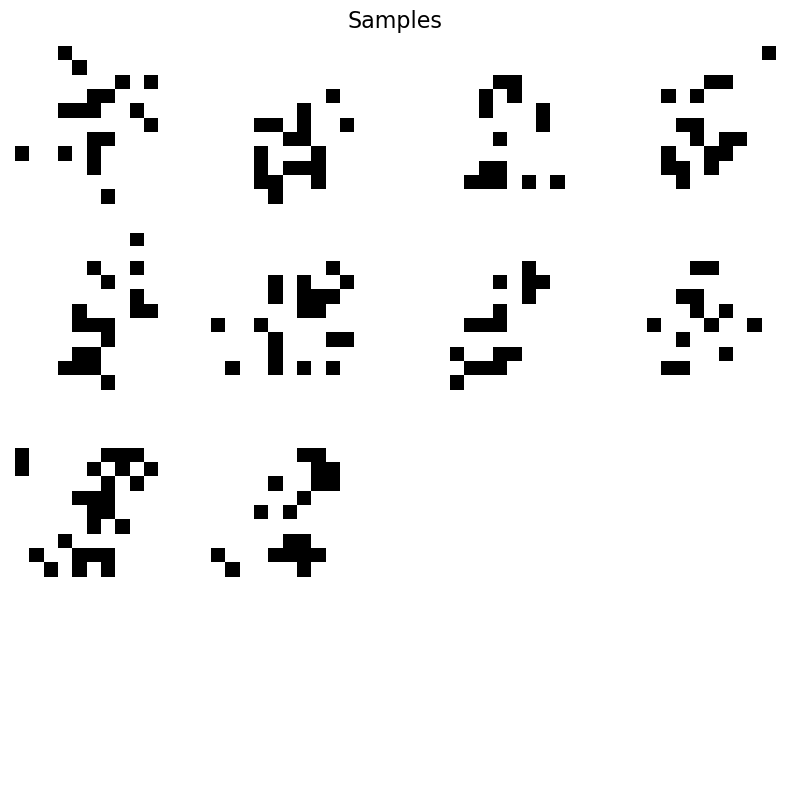

In [14]:
#--- Sampling & Visualization ---
num_gen_samples = 10
burn_in = 1000


#need to find a way to speed up these sampling functions, so slow
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples")


--- Improving samples with Tabu Search ---

Displaying Tabu Search improved images... 🖼️


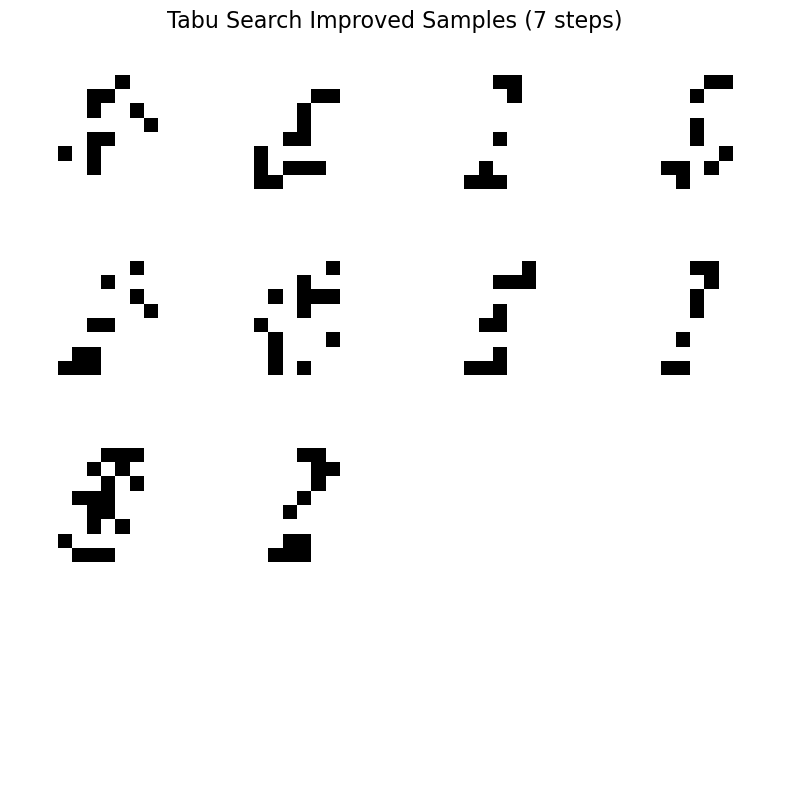

In [15]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 7
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")